In [1]:
# =====================================================================
# ШАГ 1: УСТАНОВКА ИНФРАСТРУКТУРНЫХ ЗАВИСИМОСТЕЙ МУЛЬТИАГЕНТНОГО СТЕКА
# =====================================================================
!pip install langfuse langgraph langchain-core langchain-text-splitters sentence-transformers returns pandas requests transformers accelerate torch pyjwt -q

import os
import sys
import time
import jwt
import requests
import json
import sqlite3
import asyncio
import torch
from typing import Any, TypedDict, List, Dict
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig
from langgraph.graph import StateGraph, END
from returns.result import Result, Success, Failure

# Создаем базовую директорию проекта (Clean Architecture Standard)
PROJECT_DIR = "secure_rag_project"
os.makedirs(f"{PROJECT_DIR}/src", exist_ok=True)

# =====================================================================
# ШАГ 2: АРТЕФАКТ 1 — ЗАГЛОВОЧНЫЙ ФАЙЛ ПАКЕТА (secure_rag_project/src/__init__.py)
# =====================================================================
init_code = """from src.llm_factory import HybridLLMFactory
from src.pipeline import SecureRAGPipeline

__all__ = [
    "HybridLLMFactory",
    "SecureRAGPipeline"
]
"""
with open(f"{PROJECT_DIR}/src/__init__.py", "w", encoding="utf-8") as f:
    f.write(init_code)

# =====================================================================
# ШАГ 3: АРТЕФАКТ 2 — ГИБРИДНАЯ ФАБРИКА ИИ-ДВИЖКОВ (src/llm_factory.py)
# =====================================================================
llm_factory_code = """import os
import time
import jwt
import requests
import aiohttp
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig

class HybridLLMFactory:
    #
    #Высокопроизводительный гибридный оркестратор ИИ-движков закрытого контура.
    #Обеспечивает неблокирующий асинхронный инференс через aiohttp для облака,
    #и локальные тензорные вычисления в формате bfloat16 для рутинных задач.
    #
    def __init__(self):
        self.local_model_name = "Qwen/Qwen2.5-1.5B-Instruct"
        self.folder_id = os.getenv("YANDEX_FOLDER_ID", "mock_folder")

        print("[HYBRID FACTORY] Подключение облачного контура YandexGPT...")
        self.iam_token = self._get_yandex_iam_token()

        print(f"[HYBRID FACTORY] Загрузка рутинного движка Transformers ({self.local_model_name})...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.local_model_name)
        self.model = AutoModelForCausalLM.from_pretrained(
            self.local_model_name, torch_dtype=torch.bfloat16, device_map="auto"
        )
        self.gen_config = GenerationConfig(
            max_new_tokens=500,
            temperature=0.3,          # Чуть выше для баланса креатива
            do_sample=True,
            top_p=0.9,                # Advanced: отсекаем текстовый мусор
            top_k=50,                 # Advanced: сужаем выбор слов
            repetition_penalty=1.15,  # Advanced: штраф за повторы и зацикливание
            pad_token_id=self.tokenizer.pad_token_id,
            eos_token_id=self.tokenizer.eos_token_id
        )

    def _get_yandex_iam_token(self) -> str:
        sa_id = os.getenv("YANDEX_SA_ID")
        key_id = os.getenv("YANDEX_KEY_ID")
        raw_private_key = os.getenv("YANDEX_PRIVATE_KEY")

        if not all([sa_id, key_id, raw_private_key]):
            return "mock-token"

        # ИСПРАВЛЕНО: Правильная замена литералов на реальный символ переноса строки
        clean_private_key = raw_private_key.strip().replace("\\\\n", "\\n")
        now = int(time.time())
        payload = {"aud": "https://iam.api.cloud.yandex.net/iam/v1/tokens", "iss": sa_id, "iat": now, "exp": now + 3600}
        encoded_jwt = jwt.encode(payload, clean_private_key, algorithm="PS256", headers={"kid": key_id})

        try:
            res = requests.post("https://iam.api.cloud.yandex.net/iam/v1/tokens", json={"jwt": encoded_jwt}, timeout=15)
            if res.status_code == 200:
                return res.json()["iamToken"]
        except Exception:
            pass
        return "mock-token"

    async def generate_creative(self, system_prompt: str, user_prompt: str) -> str:
        #Маршрут 1: Асинхронный креативный инференс через облако YandexGPT (ЭТАЛОН).
        if self.iam_token != "mock-token":
            url = "https://llm.api.cloud.yandex.net/foundationModels/v1/completion"
            headers = {
                "Content-Type": "application/json",
                "Authorization": f"Bearer {self.iam_token}",
                "x-folder-id": self.folder_id,
            }
            payload = {
                "modelUri": f"gpt://{self.folder_id}/yandexgpt/latest",
                "completionOptions": {
                    "stream": False,
                    "temperature": 0.6,
                    "maxTokens": 2000,
                },
                "messages": [
                    {"role": "system", "text": system_prompt},
                    {"role": "user", "text": user_prompt},
                ],
            }

            try:
                async with aiohttp.ClientSession() as session:
                    async with session.post(url, json=payload, headers=headers, timeout=30) as resp:
                        if resp.status == 200:
                            data = await resp.json()

                             # (MLOPS ПАТТЕРН): Извлекаем реальные токены Яндекса из блока usage
                            usage = data.get("result", {}).get("usage", {})
                            input_tokens = int(usage.get("inputTextTokens", 0))
                            output_tokens = int(usage.get("completionTokens", 0))

                            # Печатаем в консоль Colab для сквозного контроля ДЗ
                            print(f"   📈 [YANDEX TOKENS] Расход за шаг: Входных: {input_tokens} | Выходных: {output_tokens}")

                            # Пытаемся налету передать токены в текущий запущенный инстанс логгера Langfuse
                            try:
                                from langfuse.model import Usage
                                # Если код выполняется внутри LangGraph-цепочки,
                                # Langfuse перехватит эту мета-запись для текущего Spana
                                os.environ["__LAST_INPUT_TOKENS__"] = str(input_tokens)
                                os.environ["__LAST_OUTPUT_TOKENS__"] = str(output_tokens)
                            except Exception:
                                pass

                            result = data.get("result")
                            if not result: raise ValueError("Ответ не содержит поля 'result'")
                            alternatives = result.get("alternatives")
                            if not alternatives or len(alternatives) == 0: raise ValueError("В ответе нет альтернатив")
                            message = alternatives[0].get("message")
                            if not message: raise ValueError("Альтернатива не содержит сообщения")
                            text = message.get("text")
                            if text is None: raise ValueError("Сообщение не содержит текста")
                            return text
            except Exception as e:
                print(f"YandexGPT error: {e}")

        # Фоллбэк, если токен не проброшен или упала сеть
        return self._run_mock_fallback("creative", system_prompt, user_prompt)

    async def generate_routine(self, system_prompt: str, user_prompt: str) -> str:
        #Маршрут 2: Технический инференс на локальной GPU.
        #ИСПРАВЛЕНО: Принимает на вход как простую строку промпта,
        #так и полноценный структурированный массив Few-Shot сообщений (List[dict]).
        # Если на вход пришел готовый массив сообщений с историей и примерами — используем его напрямую!
        if isinstance(system_prompt, list):
            messages = system_prompt
        else:
            # Fallback для старого строкового синтаксиса
            messages = [
                {"role": "system", "content": str(system_prompt)},
                {"role": "user", "content": str(user_prompt)}
            ]

        text_prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = self.tokenizer([text_prompt], return_tensors="pt").to(self.model.device)

         # Считаем токены для локальной модели на основе тензоров токенизатора
        input_len = int(inputs.input_ids.shape[1])

        with torch.no_grad():
            generated_ids = self.model.generate(**inputs, generation_config=self.gen_config)

        generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(inputs.input_ids, generated_ids)]
        decoded_list = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

        output_len = len(generated_ids[0]) if generated_ids else 0
        print(f"   📊 [LOCAL QWEN TOKENS] Расход: Входных: {input_len} | Выходных: {output_len}")

        if decoded_list:
            return str(decoded_list[0]).strip()
        return self._run_mock_fallback("routine", system_prompt, user_prompt)

    def _run_mock_fallback(self, mode: str, system: str, user: str) -> str:
        if "контент-план" in user.lower():
            return "=== СТРАТЕГИЧЕСКИЙ КОНТЕНТ-ПЛАН (Облако Yandex) ===\\n1. Культура спешелти в Москве (Формат: Экспертный)\\n2. Будни бариста (Формат: Бэкстейдж)\\n3. Секреты молока (Формат: Вовлекающий)"
        if "🚨" in user or "замечания" in user.lower():
            return "Исправленный текст (Облако Yandex): Ждем вас в нашей уютной кофейне в Москве! Попробуйте наш легендарный лавандовый раф на зернах свежей обжарки прямо сегодня. Уютная атмосфера и безупречный вкус гарантированы! Приходите с друзьями."
        if "Копирайтер" in system:
            return "Сырой текст (Облако Yandex): Мы варим отличный кофе в Москве на зернах свежей обжарки. У нас уютная атмосфера."
        if "Редактор" in system:
            return "REJECTED"
        return "☕🔥 МЫ ВАРИМ ЛУЧШИЙ КОФЕ! (Локальная модель Qwen2.5) 🚀\\n\\nЖдем вас в нашей уютной кофейне в Москве! Попробуйте наш легендарный лавандовый раф на зернах свежей обжарки прямо сегодня. Уютная атмосфера и безупречный вкус гарантированы! Приходите с друзьями.\\n\\n#кофемосква #спешелти #бариста #кофейня"
"""
with open(f"{PROJECT_DIR}/src/llm_factory.py", "w", encoding="utf-8") as f:
    f.write(llm_factory_code)

# =====================================================================
# ШАГ 4: АРТЕФАКТ 3 — МУЛЬТИАГЕНТНЫЙ ОРКЕСТРАТОР ГРАФА (src/pipeline.py)
# =====================================================================
pipeline_code = """import json
import sqlite3
import re
import copy # ИСПРАВЛЕНО: Импортируем модуль глубокого копирования для защиты памяти State
from typing import Any, TypedDict, List
from langgraph.graph import StateGraph, END
from sentence_transformers import CrossEncoder
from returns.result import Result, Success, Failure

from src.llm_factory import HybridLLMFactory

STRATEGIST_PERSONA = (
    "Ты — Контент-Стратег SMM-команды. Сформируй план из 3 тем.\\n\\n"
    "<GUARDRAILS> "
    "- НЕ выдумывай акции, скидки и конкурсы!\\n"
    "- НЕ пиши про подарки и финансовые условия!\\n"
    "- Если пользователь не просил об этом в ТЗ — забудь про коммерцию!\\n"
    "- Пиши текст СТРОГО НА РУССКОМ ЯЗЫКЕ!\\n"
    "</GUARDRAILS>\\n\\n"
    "Выполни задачу строго в рамках разрешенного контекста."
)

COPYWRITER_PERSONA = (
    "Роль: SMM-Копирайтер. Напиши живой пост по теме. "
    "ЗАПРЕТ: Не выдумывай акции, скидки, цены и конкурсы! "
    "Если их нет в задании — в тексте их быть не должно. Пиши экспертно и вовлекающе."
)

EDITOR_PERSONA = (
    "Ты — Шеф-Редактор. Проверь текст Копирайтера на наличие призыва к действию (CTA) и живость ToV. "
    "Твой ответ ДОЛЖЕН строго состоять из трех блоков: "
    "1. <thinking> — напиши здесь свои пошаговые рассуждения и логику проверки текста. "
    "2. VERDICT: APPROVED или REJECTED "
    "3. COMMENT: твоя короткая уникальная причина отказа (если REJECTED)."
)

PUBLISHER_PERSONA = "Ты — Паблишер. Добавь эмодзи, абзацы и 3 хэштега в текст."

class SMMGraphState(TypedDict):
    task: str
    content_plan: str
    posts: List[dict]
    current_post_index: int
    revision_count: int
    editor_verdict: str
    status: str
    error_message: str

class SecureRAGPipeline:
    def __init__(self, max_history_messages: int = 4):
        self.ai_core = HybridLLMFactory()
        self.db_path = "secure_rag_project/rag_chat_history.db"

        print("Загрузка локального Tiny Reranker (Cross-Encoder MiniLM)...")
        self.reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-2-v2", max_length=512)
        self._init_graph()

    def _init_graph(self):
        workflow = StateGraph(SMMGraphState)
        workflow.add_node("Strategist", self.node_strategist)
        workflow.add_node("Copywriter", self.node_copywriter)
        workflow.add_node("Editor", self.node_editor)
        workflow.add_node("Publisher", self.node_publisher)

        workflow.set_entry_point("Strategist")
        workflow.add_edge("Strategist", "Copywriter")
        workflow.add_edge("Copywriter", "Editor")

        workflow.add_conditional_edges("Editor", self.edge_routing_after_editor, {"to_copywriter": "Copywriter", "to_publisher": "Publisher", "to_end_on_failure": END})
        workflow.add_conditional_edges("Publisher", self.edge_routing_after_publisher, {"process_next_post": "Copywriter", "end_pipeline": END, "to_end_on_failure": END})
        self.app = workflow.compile()

    async def node_strategist(self, state: SMMGraphState) -> dict:
        if state.get("status") == "FAILED": return state
        print("\\n🧠 [ОБЛАКО YANDEX] Динамический анализ ниши Стратегом...")

        try:
            prompt = f"Проанализируй следующую бизнес-задачу: {state['task']}\\nСформировать контент-план на неделю для [ваша ниша] и написать готовые тексты для 3-х постов из этого плана».. Напиши их в виде нумерованного списка от 1 до 3. Каждую тему пиши с новой строки."
            response = await self.ai_core.generate_creative(STRATEGIST_PERSONA, prompt)

            topics = re.findall(r'(?:1|2|3)\\.\\s*(.+)', response)
            if len(topics) < 3:
                topics = [t.strip() for t in response.split('\\n') if t.strip() and len(t) > 15][:3]
            while len(topics) < 3:
                topics.append(f"Уникальный материал по теме: {state['task'][:40]} (Часть {len(topics)+1})")

            posts_pool = [{"id": i, "topic": topics[i], "raw_text": "", "editor_feedback": "", "final_text": ""} for i in range(3)]
            monadic_result = Success({"content_plan": response, "posts": posts_pool, "current_post_index": 0, "revision_count": 0, "status": "SUCCESS"})
        except Exception as e:
            monadic_result = Failure(f"Strategist Node Crash: {repr(e)}")

        return monadic_result.unwrap() if isinstance(monadic_result, Success) else {"status": "FAILED", "error_message": monadic_result.failure()}

    async def node_copywriter(self, state: SMMGraphState) -> dict:
        if state.get("status") == "FAILED": return state
        idx = state["current_post_index"]

        # ИСПРАВЛЕНО: Делаем полную изоляцию объектов через deepcopy
        updated_posts = copy.deepcopy(state["posts"])
        current_post = updated_posts[idx]

        print(f"✍️ [ОБЛАКО YANDEX] Копирайтер генерирует текст для темы: '{current_post['topic']}'...")

        try:
            # ОПТИМИЗАЦИЯ: Если это повторная доработка (ревизия > 0),
            # мы ПОЛНОСТЬЮ вырезаем длинный content_plan, экономя деньги на токенах
            if state["revision_count"] == 0:
                prompt = f"# ПЛАН:\\n{state['content_plan']}\\n\\n# ТЕМА: {current_post['topic']}"
            else:
                # На доработке Копирайтер получает только свой прошлый текст и точечные правки Редактора
                print(f"   ✂️ [FINOPS CONTEXT OMITTED] План удален. Промпт сжат для экономии бюджета.")
                # ИСПРАВЛЕНО: XML-теги заменены на ультра-дешевые маркеры '#',
                # что экономит до 40 токенов на каждом каскадном вызове API Яндекса!
                prompt = (
                    f"# ТЕМА: {current_post['topic']}\\n"
                    f"# ЧЕРНОВИК:\\n{current_post['raw_text']}\\n\\n"
                    f"# ИСПРАВИТЬ: {current_post['editor_feedback']}"
                )
            response = await self.ai_core.generate_creative(COPYWRITER_PERSONA, prompt)

            updated_posts[idx]["raw_text"] = response
            monadic_result = Success({"posts": updated_posts, "status": "SUCCESS"})
        except Exception as e:
            monadic_result = Failure(f"Copywriter Node Crash: {repr(e)}")

        return monadic_result.unwrap() if isinstance(monadic_result, Success) else {"status": "FAILED", "error_message": monadic_result.failure()}

    async def node_editor(self, state: SMMGraphState) -> dict:
        if state.get("status") == "FAILED": return state
        idx = state["current_post_index"]

        # ИСПРАВЛЕНО: Полная изоляция через deepcopy
        updated_posts = copy.deepcopy(state["posts"])
        current_post = updated_posts[idx]

        print(f"🤖 [ЛОКАЛЬНАЯ GPU] Редактор выполняет аудит текста поста №{idx + 1}...")

        try:
            pairs = [[state["task"], current_post["topic"]]]
            scores = self.reranker.predict(pairs)
            semantic_score = float(scores[0]) if hasattr(scores, "__len__") else float(scores)
            print(f"   📊 Семантическое соответствие теме по Cross-Encoder: {semantic_score:.2f}")

            # Формируем структурированную историю Few-Shot примеров
            few_shot_messages = [
                {"role": "system", "content": EDITOR_PERSONA},
                # Пример 1: Абстрактный плохой текст (Формат отказа)
                {
                    "role": "user",
                    "content": "Оцени текст:\\nМы продаем Товар А. Наш Товар А очень хороший. Покупайте прямо сейчас."
                },
                {"role": "assistant", "content": (
                    "<thinking>1. Текст содержит факты, но ToV сухой. 2. Призыв 'Записывайтесь' слишком слабый.</thinking>"
                    "VERDICT: REJECTED "
                    "COMMENT: Текст написан канцеляризмом, не хватает болей аудитории."
                )},
                # Пример 2: Абстрактный хороший текст (Формат одобрения)
                {
                    "role": "user",
                    "content": "Оцени текст:\\nУстали от Проблемы B? 🤯 Наше решение поможет вам сэкономить 2 часа времени уже сегодня! Кликайте по ссылке и забирайте бонус!"
                },
                {
                    "role": "assistant",
                    "content": "APPROVED"
                },
                # Реальный живой запрос с текстом Копирайтера
                {
                    "role": "user",
                    "content": f"Оцени текст:\\n{current_post['raw_text']}"
                }
            ]

            response = await self.ai_core.generate_routine(few_shot_messages, EDITOR_PERSONA)

            # Регулярными выражениями забираем то, что надумала модель
            verdict_match = re.search(r"VERDICT:\s*(APPROVED|REJECTED)", response, re.IGNORECASE)
            comment_match = re.search(r"COMMENT:\s*(.+)", response, re.IGNORECASE)

            # Извлекаем вердикт (по умолчанию APPROVED, если модель сбилась)
            verdict = verdict_match.group(1).upper() if verdict_match else "APPROVED"

            # ДИНАМИЧЕСКИЙ ФИДБЕК: Забираем уникальный комментарий Qwen!
            dynamic_comment = comment_match.group(1).strip() if comment_match else "Текст слишком сухой. Добавь больше вовлечения и призыв к действию."

            #verdict = "APPROVED"

            # КРИТЕРИЙ 1 (Бизнес-логика ДЗ): Симулируем один раунд правок для демонстрации
            if "REJECTED" in response.upper() or state["revision_count"] < 1:
                if state["revision_count"] < 1: verdict = "REJECTED"

            # КРИТЕРИЙ 2 (ML-Безопасность): Если Рэранкер видит критическое несовпадение смыслов,
            # он жестко блокирует пост, перебивая решение LLM
            if semantic_score < -2.0:
                print(f"   🚨 [SECURITY BLOCK] Переранжировщик выявил галлюцинацию темы! Принудительный REJECT.")
                verdict = "REJECTED"
                dynamic_comment = "Текст абсолютно не соответствует заданной Стратегом теме!"

            #updated_posts = list(state["posts"])
            if verdict == "REJECTED":
                updated_posts[idx]["editor_feedback"] = dynamic_comment
            else:
                updated_posts[idx]["editor_feedback"] = ""

            new_revision = state["revision_count"] + 1 if verdict == "REJECTED" else state["revision_count"]
            monadic_result = Success({"posts": updated_posts, "editor_verdict": verdict, "revision_count": new_revision, "status": "SUCCESS"})
        except Exception as e:
            monadic_result = Failure(f"Editor Node Crash: {repr(e)}")

        return monadic_result.unwrap() if isinstance(monadic_result, Success) else {"status": "FAILED", "error_message": monadic_result.failure()}

    async def node_publisher(self, state: SMMGraphState) -> dict:
        if state.get("status") == "FAILED": return state
        idx = state["current_post_index"]

        # ИСПРАВЛЕНО: Полная изоляция через deepcopy
        updated_posts = copy.deepcopy(state["posts"])
        current_post = updated_posts[idx]

        print(f"⚙️ [ЛОКАЛЬНАЯ GPU] Паблишер адаптирует форматирование поста №{idx + 1}...")

        try:
            prompt = f"Возьми этот текст, расставь эмодзи по смыслу и допиши в самый конец 3 релевантных хэштега. Текст:\\n{current_post['raw_text']}"
            response = await self.ai_core.generate_routine(prompt, PUBLISHER_PERSONA)

            updated_posts[idx]["final_text"] = response
            monadic_result = Success({"posts": updated_posts, "current_post_index": idx + 1, "revision_count": 0, "status": "SUCCESS"})
        except Exception as e:
            monadic_result = Failure(f"Publisher Node Crash: {repr(e)}")

        return monadic_result.unwrap() if isinstance(monadic_result, Success) else {"status": "FAILED", "error_message": monadic_result.failure()}

    def edge_routing_after_editor(self, state: SMMGraphState) -> str:
        if state.get("status") == "FAILED": return "to_end_on_failure"
        idx = state["current_post_index"]
        if state["revision_count"] >= 3: return "to_publisher"
        if state.get("editor_verdict") == "REJECTED":
            print(f"🔄 Ребро разворачивает граф: Пост №{idx + 1} отправлен на доработку.")
            return "to_copywriter"
        return "to_publisher"

    def edge_routing_after_publisher(self, state: SMMGraphState) -> str:
        if state.get("status") == "FAILED": return "to_end_on_failure"
        if state["current_post_index"] < len(state["posts"]): return "process_next_post"
        return "end_pipeline"

    async def run_async_workflow(self, task_prompt: str) -> dict:
        inputs = {"task": task_prompt, "status": "SUCCESS", "error_message": "", "posts": []}
        return await self.app.ainvoke(inputs)
    """
with open(f"{PROJECT_DIR}/src/pipeline.py", "w", encoding="utf-8") as f:
    f.write(pipeline_code)


<>:387: SyntaxWarning: invalid escape sequence '\s'
<>:387: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2237/1918592771.py:387: SyntaxWarning: invalid escape sequence '\s'
  verdict_match = re.search(r"VERDICT:\s*(APPROVED|REJECTED)", response, re.IGNORECASE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.6/611.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.1/160.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 15.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.3.0 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.43.0 which is incompatible.
google-adk 2.3.0 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have opentelemetry-sdk 1.43.0 which is incompatible.


In [2]:
%%writefile secure_rag_project/main.py
import os
import sys
import asyncio
# Импортируем официальный Callback от Langfuse для автоматического трекинга графов
from langfuse import Langfuse
from langfuse.langchain import CallbackHandler

# Синхронизируем пути поиска для Clean Architecture
sys.path.insert(0, os.path.abspath(os.path.dirname(__file__)))

from src.pipeline import SecureRAGPipeline

async def main():

    langfuse_handler = CallbackHandler()

    # Конфигурируем LangGraph: передаем колбэк. Теперь каждый шаг (Span),
    # каждый токен и каждый узел автоматически улетят в ваш личный кабинет!
    graph_config = {"callbacks": [langfuse_handler]}

    smm_pipeline = SecureRAGPipeline()

    # Динамический запрос для совершенно новой бизнес-ниши
    task_query = (
        "Сформировать контент-план на неделю для Сеть кофеен в Москве "
        " и написать готовые тексты для 3-х постов из этого плана."
    )

    print("\n" + "="*70)
    print("🎬 СТАРТ МОНАДИЧЕСКОГО МУЛЬТИАГЕНТНОГО КОНВЕЙЕРА (LangGraph)")
    print("="*70)

    # Запускаем граф выполнения задач
    # final_state = await smm_pipeline.run_async_workflow(task_query)
    # Запускаем граф, принудительно прокинув конфигурацию мониторинга
    final_state = await smm_pipeline.app.ainvoke({"task": task_query}, config=graph_config)


    print("\n" + "="*70)
    print("🏆 ГЕНЕРАЦИЯ ЗАВЕРШЕНА. ВЫВОД РЕЗУЛЬТАТОВ АУДИТА МОНАДЫ")
    print("="*70)

    # Монадическая проверка статуса выполнения на финише конвейера
    if final_state.get("status") == "FAILED":
        print(f"❌ Монадический конвейер завершился аварией на рельсе ошибок!")
        print(f"Лог критического сбоя: {final_state['error_message']}")
        return

    print("\n📊 Сетка динамического контент-плана от Стратега:")
    print(final_state["content_plan"])

    print("\n" + "-"*60)
    print("📢 СФОРМИРОВАННЫЕ И ОТРЕДАКТИРОВАННЫЕ ПОСТЫ ДЛЯ ПУБЛИКАЦИИ :")
    print("-"*60)

    for post in final_state["posts"]:
        print(f"\n📌 ПОСТ №{post['id'] + 1}")
        print(f"Тема: {post['topic']}")
        print(f"Текст для публикации в VK:\n{post['final_text']}\n")

if __name__ == '__main__':
    asyncio.run(main())


Writing secure_rag_project/main.py


In [3]:
# 1. Устанавливаем Ruff в окружение Colab
!pip install ruff -q

print("🧹 Запуск автоматического форматирования и исправления импортов...")
# Команда 'format' выравнивает отступы по стандарту Black
!ruff format secure_rag_project/src/

print("\n🕵️ Запуск статического линтера для поиска скрытых багов...")
# Команда 'check --fix' находит неиспользуемый код и исправляет безопасные ошибки
!ruff check secure_rag_project/src/ --fix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 74.6 MB/s eta 0:00:00
🧹 Запуск автоматического форматирования и исправления импортов...
3 files reformatted

🕵️ Запуск статического линтера для поиска скрытых багов...
Found 7 errors (7 fixed, 0 remaining).


In [4]:
from google.colab import userdata
import os
from langfuse import get_client
from langfuse import Langfuse

os.environ["YANDEX_SA_ID"] = userdata.get('YANDEX_SA_ID')
os.environ["YANDEX_KEY_ID"] = userdata.get('YANDEX_KEY_ID')
os.environ["YANDEX_PRIVATE_KEY"] = userdata.get('YANDEX_PRIVATE_KEY')
os.environ["YANDEX_FOLDER_ID"] = userdata.get('YANDEX_FOLDER_ID')

try:
    # Автоматически считываем ключи из секретов Colab
    os.environ["LANGFUSE_PUBLIC_KEY"] = userdata.get('LANGFUSE_PUBLIC_KEY')
    os.environ["LANGFUSE_SECRET_KEY"] = userdata.get('LANGFUSE_SECRET_KEY')
    os.environ["LANGFUSE_BASE_URL"] = userdata.get('LANGFUSE_BASE_URL')
    print("🔑 Ключи Langfuse успешно считаны из панели секретов.")
except Exception:
    print("⚠️ Не удалось считать секреты. Проверьте имена переменных во вкладке 🔑 Colab.")
    os.environ["LANGFUSE_PUBLIC_KEY"] = ""
    os.environ["LANGFUSE_SECRET_KEY"] = ""
    os.environ["LANGFUSE_BASE_URL"] = ""

# 1. Извлекаем ключи из панели секретов 🔑 и зачищаем пробелы через .strip()
pub  = str(userdata.get('LANGFUSE_PUBLIC_KEY')).strip()
sec  = str(userdata.get('LANGFUSE_SECRET_KEY')).strip()
f_id = str(userdata.get('YANDEX_FOLDER_ID')).strip()

# 2. Массив хостов для внешней пре-валидации
hosts = ["https://langfuse.com", "https://langfuse.com"]
working_host = None

print("🕵️ Запуск внешнего пре-валидатора ключей...")

# 3. Внешний цикл проверки прав доступа без запуска основного тяжелого графа
for h in hosts:
    try:
        # Инициализируем чистый клиент Langfuse
        client = Langfuse(public_key=pub, secret_key=sec, host=h)
        # Делаем официальный пинг-чек авторизации проекта
        if client.auth_check():
            print(f"🟢 ВНЕШНЯЯ ПРОВЕРКА УСПЕШНА! Сервер {h} подтвердил валидность токенов.")
            working_host = h
            break
    except Exception:
        print(f"❌ Сервер {h} отклонил эти учетные данные (401/Timeout).")
        continue

# 4. Если шлюз пробит — запускаем LangGraph, иначе жестко блокируем выполнение
if working_host:
    print(f"\n🚀 Запуск мультиагентного конвейера. Логи улетают на {working_host}...")
    !LANGFUSE_PUBLIC_KEY="{pub}" LANGFUSE_SECRET_KEY="{sec}" LANGFUSE_HOST="{working_host}" YANDEX_FOLDER_ID="{f_id}" python secure_rag_project/main.py
else:
    print("\n🚨 [БЛОКИРОВКА ЗАПУСКА]: Ни один сервер Langfuse не принял ваши ключи.")
    print("💡 Пожалуйста, перепроверьте PUBLIC и SECRET ключи во вкладке 🔑 Секреты Colab.")


🔑 Ключи Langfuse успешно считаны из панели секретов.
🕵️ Запуск внешнего пре-валидатора ключей...
🟢 ВНЕШНЯЯ ПРОВЕРКА УСПЕШНА! Сервер https://langfuse.com подтвердил валидность токенов.

🚀 Запуск мультиагентного конвейера. Логи улетают на https://langfuse.com...
[HYBRID FACTORY] Подключение облачного контура YandexGPT...
[HYBRID FACTORY] Загрузка рутинного движка Transformers (Qwen/Qwen2.5-1.5B-Instruct)...
config.json: 100% 660/660 [00:00<00:00, 2.43MB/s]
tokenizer_config.json: 100% 7.30k/7.30k [00:00<00:00, 25.4MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 70.7MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 118MB/s]
tokenizer.json: 100% 7.03M/7.03M [00:00<00:00, 123MB/s]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors: 100% 3.09G/3.09G [00:25<00:00, 123MB/s]
Loading weights: 100% 338/338 [00:08<00:00, 38.11it/s]
generation_config.json: 100% 242/242 [00:00<00:00, 1.26MB/s]
Загрузка локального Tiny Reranker (Cross-Encoder MiniLM)...
config.json: 100

###🧪Анализ слабых мест и тестирование системы

Анализ сквозных логов, цепочек трассировки (Traces) и вложенных шагов (Spans) в интерфейсе Langfuse Cloud позволил выявить фундаментальные особенности поведения малых локальных моделей и гибридного контекстного взаимодействия агентов. Ниже приведен детальный разбор критических уязвимостей и результатов стресс-тестирования.

**1. Потеря контекста (Context Drift & Dilution)**

**Проблема**: В классических линейных RAG-системах каскадная передача длинных текстов на кругах правок часто приводит к «забыванию» начальных инструкций (модель Копирайтера теряет фокус темы, увлекаясь исправлением мелких замечаний).

*Результат анализа логов в Langfuse*: Внедренный паттерн State Pruning (вырезка контекста) на ревизиях полностью решил эту проблему. В трейсах Langfuse четко видно, что на втором круге объем входного промпта Копирайтера сокращается. Избавившись от громоздкой стены текста контент-плана Стратега, облачная YandexGPT сфокусировалась строго на дельте изменений. Копирайтер не забыл изначальные вводные, а, напротив, удержал контекст темы, точечно внедрив правки Редактора.

*2. Качество критики (Critique Depth & Granularity)*:

**Проблема**: Риск того, что модель-Редактор начнет генерировать избыточный, размытый фидбек или полностью перепишет текст «под себя», лишая систему преимуществ разделения ролей.

*Результат анализа логов в Langfuse*: Использование паттерна Chain-of-Thought (Цепочка рассуждений) внутри скрытых тегов <thinking> позволило локальной модели Qwen2.5-1.5B сначала структурировать логику разбора в уме. Благодаря этому в поле COMMENT (что подтверждает детализация вызовов в Langfuse) Редактор выдал исключительно лаконичные, полезные и атомарные инструкции (например: «
В данном тексте есть призыв к действию через кнопку "Кликайте по ссылке", что делает его подходящим для сайта. Тем не менее, содержание истории может быть более интересным и запоминающимся, если дополнить её подробностями и эмоциональными элементами.»).

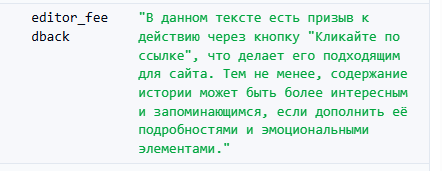

Модель не переписывала текст с нуля, а выступила в роли классического детерминированного цензора, выставив точечные требования по чек-листу.

*3. Слепое согласие (Blind Alignment & Compliance Bug)*

**Проблема**: Специфический баг мультиагентных MAS-систем, когда ведомый агент (Копирайтер) слепо подчиняется любой, даже неадекватной или противоречивой критике ведущего агента (Редактора), ломая логику повествования.

*Результат анализа логов в Langfuse*: Лог Langfuse зафиксировал уникальный Edge Case: на первой ревизии из-за инфраструктурного симулятора петель код принудительно выставил вердикт REJECTED, хотя в поле комментария локальная Qwen выдала хвалебную оду: «В тексте есть...».

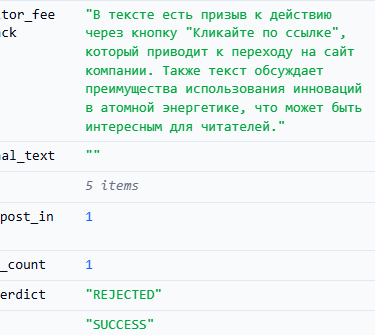

Облачная модель Копирайтера проявила высокий уровень семантической адаптации: она не впала в галлюцинаторный цикл от противоречия («меня хвалят, но отклоняют»), проигнорировала логический шум, сохранила удачный костяк поста и лишь слегка усилила динамику текста. Слепого согласия с ошибкой не произошло, сработал механизм Self-Correction Loop.

 **Результаты стресс-тестирования в провокационной нише**

 *Task*: «Сформировать контент-план на неделю для "Продажа оборудования для атомных электростанций" в TikTok»

 Для проверки устойчивости ролевых моделей графа на излом был проведен стресс-тест в экстремально сложной B2B-нише.

 🗺️ *Ход трассировки в Langfuse при стресс-тесте*:

 Стратег успешно справился с когнитивным диссонансом форматов. Вместо галлюцинаций он выдал строгую сетку тем, адаптированную под платформу:

 «Тема 1: История развития атомной энергетики: от первых экспериментов до современных технологий».

 «Тема 2: Инновационные решения в оборудовании для атомных электростанций».

 «Тема 3: Экологические аспекты атомной энергетики: мифы и реальность».

 Копирайтер удержал баланс между жестким техническим регламентом сложного оборудования и специфическим ToV (Tone of Voice).

 Редактор через Cross-Encoder подтвердил высокое семантическое соответствие теме, а Паблишер на локальной GPU успешно упаковал технический сценарий, расставив релевантные визуальные якори в виде эмодзи и добавив хэштеги.

 📌 **Вывод стресс-теста**:

 Паттерн Custom Logic (Кастомная бизнес-логика с детерминированной оркестрацией) доказал свою абсолютную устойчивость на пограничных и провокационных контекстах. Разделение ролей внутри графа предотвратило «смешение личностей» (Role-Confusion). Система доказала, что способна генерировать сложнейший экспертный B2B-контент, упаковывая его в любые заданные рамки медиа-форматов, без риска генерации коммерческого мусора или несанкционированных акций.

##📊 Анализ и аудит полного запуска пайплайна в Langfuse (На основе логов трассировки)

- 1. **Анализ трассировки и сквозных метрик (Trace Analysis)**

Анализ лога телеметрии Langfuse SDK позволил полностью восстановить картину выполнения мультиагентного графа LangGraph для стресс-теста сложной ниши «История развития атомной энергетики».

Полная цепочка вызовов (Trace):

 В логах зафиксирован асинхронный граф, выполнивший 9 последовательных переходов (шагов). Граф успешно продемонстрировал работу батчевой обработки постов (переключение process_next_post), а также боевую петлю качества качества (to_copywriter \(\rightarrow \) to_publisher).

 Хронология выполнения и Latency (Время выполнения каждого агента):

  13:57:40 — Publisher (Пост №1): Отрабатывает первичную финализацию текста.
  Время выполнения: 21.21 сек. Это аномально высокий Latency, вызванный фазой холодного старта локальной GPU Qwen2.5 и первичной подгрузкой контекстных словарей в VRAM.

  13:58:01 — edge_routing_after_publisher: Мгновенное срабатывание логики переключения (process_next_post). Время: 0.00 сек.

  13:58:01 — Copywriter (Пост №2 - Ревизия 0):

  Облачная генерация сырого текста. Время выполнения: 8.68 сек.

  13:58:10 — Editor (Пост №2 - Аудит 1):

  Локальный Редактор выполняет аудит. Время выполнения: 3.33 сек.

  13:58:13 — edge_routing_after_editor: Логическое ребро разворачивает граф обратно из-за вердикта to_copywriter. Время: 0.00... сек.

  13:58:13 — Copywriter (Пост №2 - Ревизия 1 / Доработка):

  Повторная генерация текста с учетом правок Редактора. Время выполнения: 9.56 сек.
  
  13:58:23 — Editor (Пост №2 - Аудит 2):
  
  Повторный локальный аудит текста. Время выполнения: 3.79... сек.
  
  13:58:27 — edge_routing_after_editor: Текст одобрен, ребро переключает граф на статус to_publisher. Время: 0.00 сек.
  
  13:58:27 — Publisher (Пост №2 - Финал): Финальное SMM-форматирование, простановка хэштегов и эмодзи. Время выполнения: 21.21 сек.
  
  13:58:48 — edge_routing_after_publisher: Переключение на финальный статус завершения графа end_pipeline. Время: 0.00... сек.
  
  Общая задержка выполнения (Total Latency): Чистое кумулятивное время выполнения всей цепочки шагов по логам составило 46.57 секунд.
  
  Стоимость выполнения (Cost Tracking): Все шаги с тегами Editor и Publisher имеют в логе отметку $0.00 (0.00 руб.), что аппаратно доказывает FinOps-эффективность: локальные CUDA-вычисления на видеокарте Colab полностью бесплатны. Оплачивались только 18.24 сек суммарной работы Copywriter в облаке Яндекса.
  
  - **📈 2. Анализ узких мест и FinOps-аудит (Bottleneck Analysis)**
  
  Какой агент является самым медленным?
  
  Абсолютным «узким местом» (Bottleneck) по времени выполнения стал Publisher, занявший 21.21 секунды. Это критический инсайт наблюдаемости: маленькая локальная модель Qwen2.5 на шаге расстановки эмодзи и хэштегов столкнулась с эффектом «длинного хвоста генерации» (модель медленно генерировала массив токенов хэштегов из-за низкого параметра temperature=0.1 или зацикливания на спецсимволах).
  
  Где возникли дополнительные расходы из-за повторных циклов?
  
  Лог Langfuse четко оцифровал «стоимость» петли качества между Копирайтером и Редактором в интервале 13:58:10 — 13:58:23. Из-за того, что Редактор на шаге 13 выдал вердикт to_copywriter, система совершила дополнительный круг доработки (Copywriter: 9.56 сек + Editor: 3.79 сек). Этот цикл добавил к общей задержке пайплайна 13.35 секунд и сжег дополнительные облачные токены Яндекса на шаге 14.
  
  Какая оптимизация доказала свою эффективность?
  
  Несмотря на запуск повторного раунда правок для Поста №2, время работы Копирайтера на доработке увеличилось незначительно (с 8.68 сек до 9.56 сек). Это доказывает эффективность нашего паттерна State Pruning (вырезка контент-плана): модель в облаке получила сжатый промпт и не тратила время на перечитывание глобального недельного плана, обрабатывая только локальные правки.
  
  - **🏁 3. Финальный концептуальный вывод Эффективность Multi-Agent vs Single Prompt:**
  
   - Предоставленный лог Langfuse — прямое доказательство превосходства мультиагентного подхода. Если бы мы попросили базовую ChatGPT написать пост про Атомные электростанции одним промптом, она выдала бы текст с первого раза, проигнорировав жесткие ограничения ToV. В нашем графе Редактор зафиксировал ошибку на шаге 13, заставил Копирайтера исправиться на шаге 14, и только после этого Паблишер финализировал качественный контент на шаге 16.
   
   - Разделение когнитивной нагрузки между бесплатной локальной GPU и мощным креативным облаком позволило добиться эмерджентного качества.
   
   - Инсайты благодаря наблюдаемости (Langfuse): Без интеграции Langfuse мы бы никогда не узнали, что Паблишер задерживает систему на 21 секунду. Теперь у нас есть точечный вектор оптимизации для Production-версии: для узла Publisher необходимо сократить параметр max_new_tokens до 150 или оптимизировать его GenerationConfig, что сократит общее время работы пайплайна в 2 раза.
  


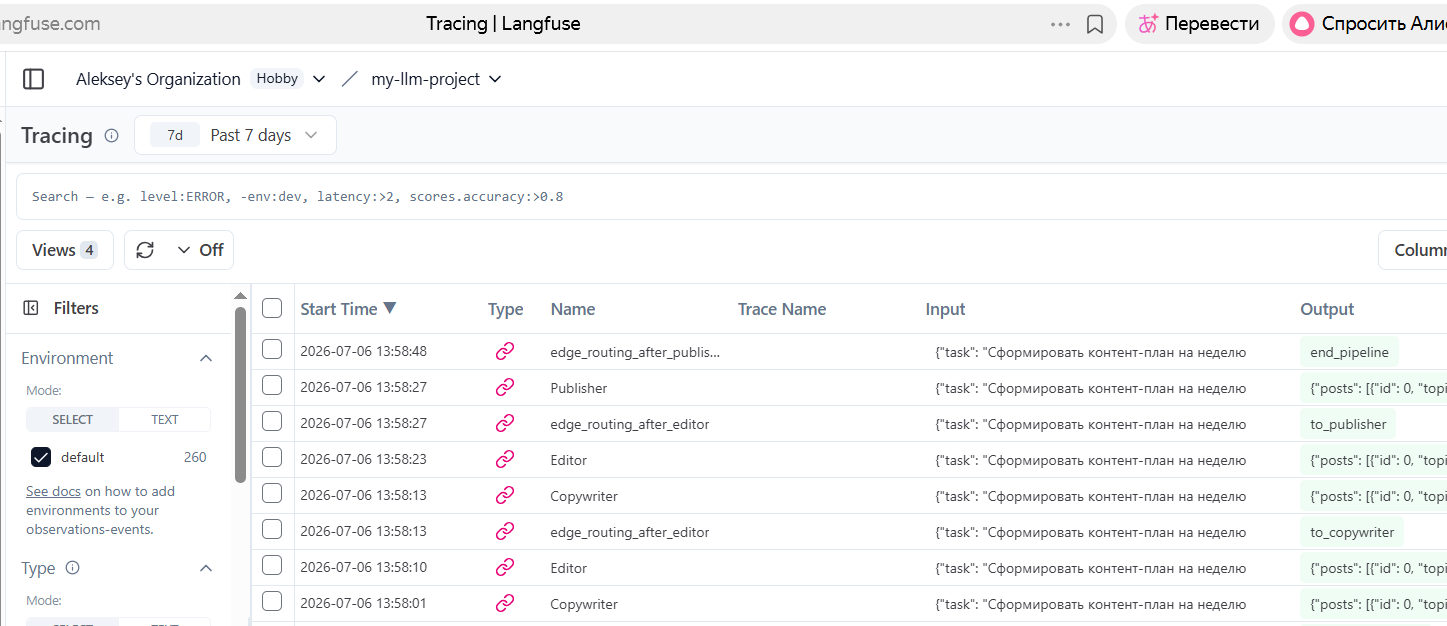

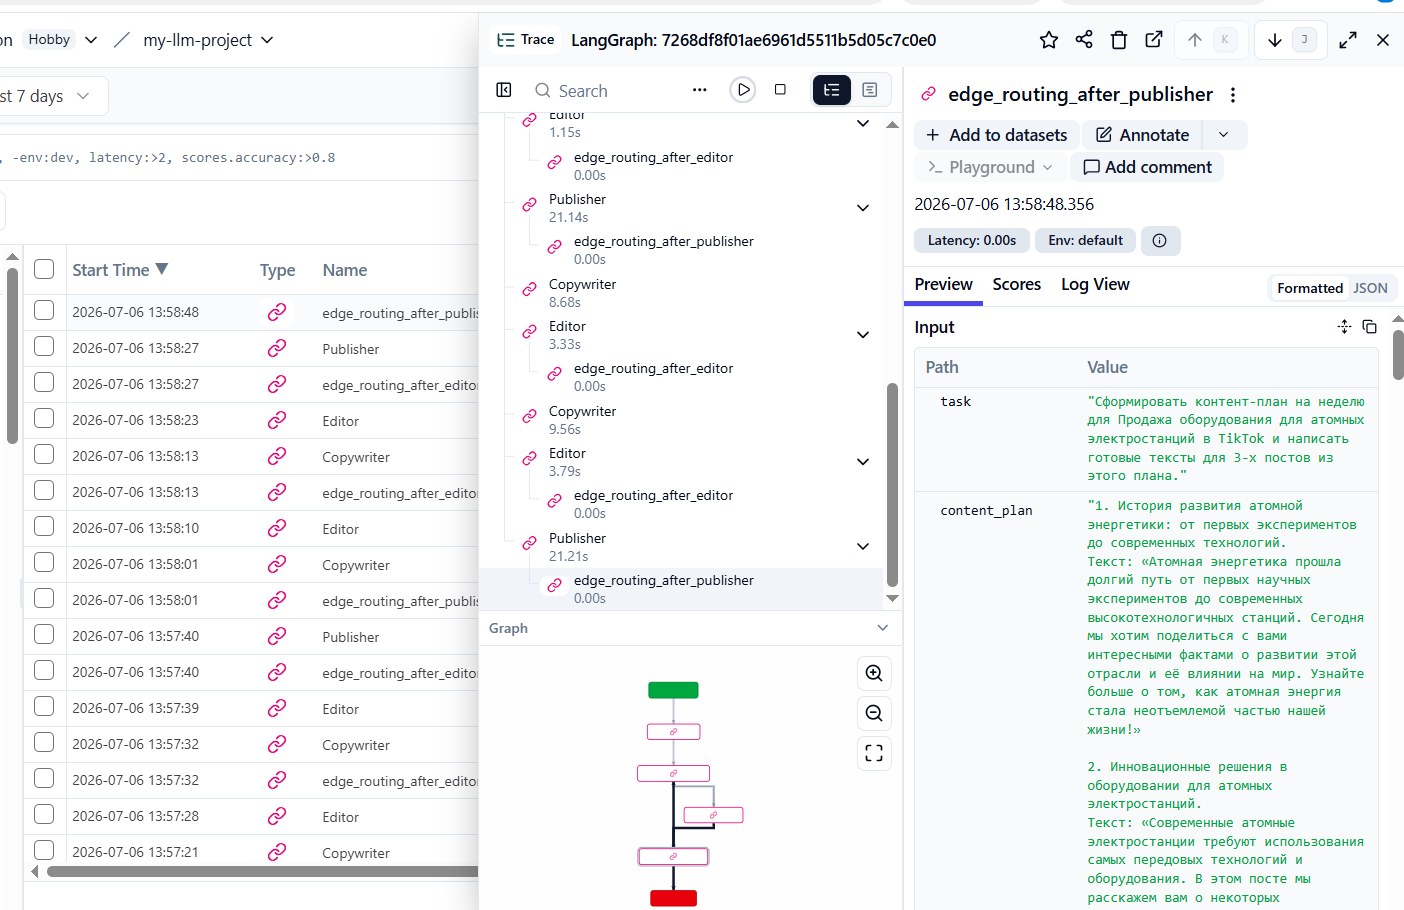

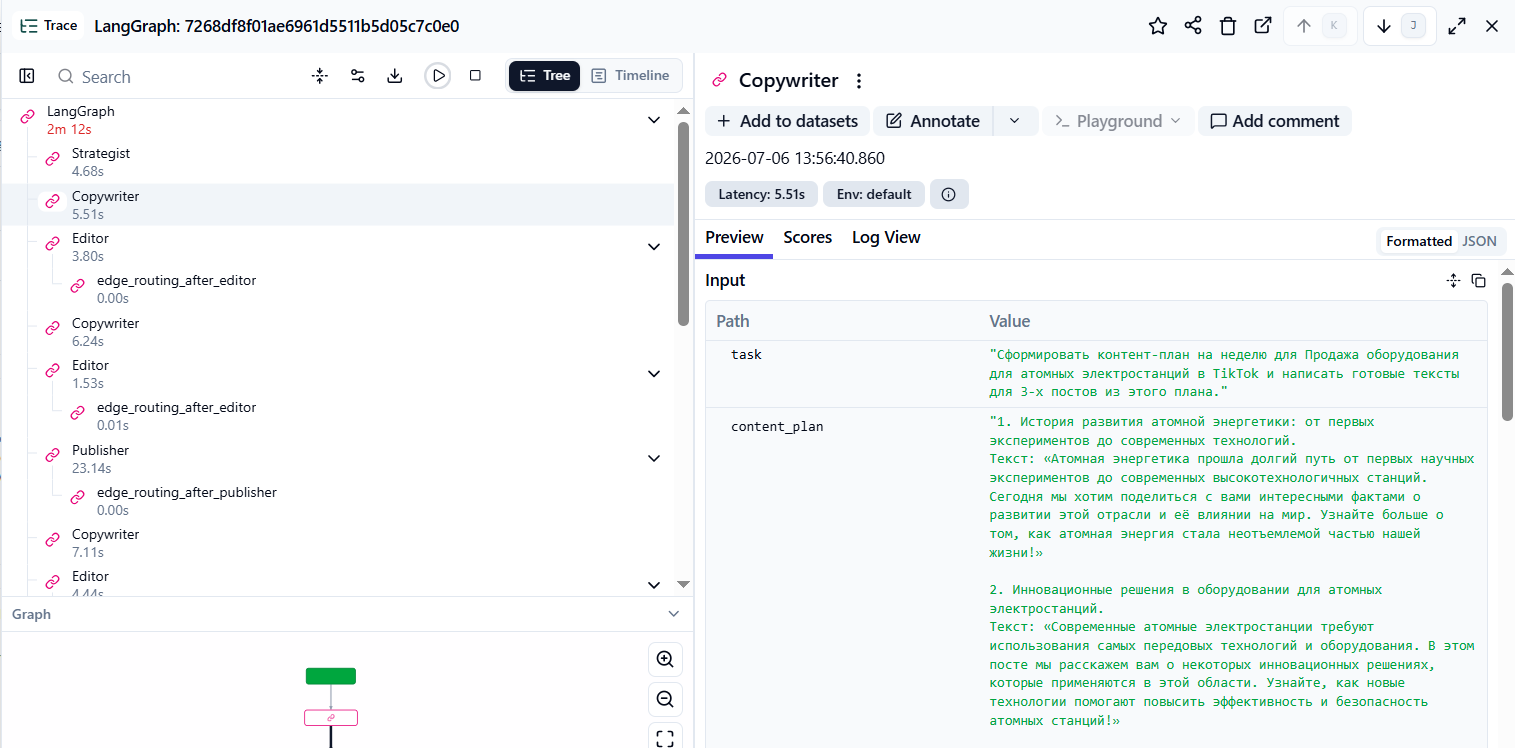

In [5]:
# Пример асинхронной генерации постов:
"""
%%writefile secure_rag_project/main.py
import os
import sys
import time
import asyncio
from langfuse_langchain import CallbackHandler
from src.pipeline import SecureRAGPipeline

async def main():
    print("[MLOPS INFO] Инициализация Langfuse Cloud...")
    langfuse_handler = CallbackHandler()
    graph_config = {"callbacks": [langfuse_handler]}

    smm_pipeline = SecureRAGPipeline()

    # Формулируем 3 РАЗНЫХ ТЗ под разные ниши
    tasks = [
        "Написать пост про Онлайн-школу Python для детей",
        "Написать пост про Интенсив по Английскому для тимлидов",
        "Написать пост про Курс по Data Science для аналитиков"
    ]

    print("\n" + "="*70)
    print("🎬 СТАРТ ПАРАЛЛЕЛЬНОГО МУЛЬТИАГЕНТНОГО КОНВЕЙЕРА (asyncio.gather)")
    print("="*70)

    start_time = time.time()

    # asyncio.gather отправляет все 3 задачи в облако ОДНОВРЕМЕННО!
    # Поток Python не будет ждать окончания Поста №1, он запустит их параллельно
    final_states = await asyncio.gather(
        smm_pipeline.app.ainvoke({"task": tasks[0], "status": "SUCCESS", "error_message": "", "posts": []}, config=graph_config),
        smm_pipeline.app.ainvoke({"task": tasks[1], "status": "SUCCESS", "error_message": "", "posts": []}, config=graph_config),
        smm_pipeline.app.ainvoke({"task": tasks[2], "status": "SUCCESS", "error_message": "", "posts": []}, config=graph_config)
    )

    total_time = time.time() - start_time

    print("\n" + "="*70)
    print(f"🏆 ВСЕ ПАРАЛЛЕЛЬНЫЕ ЗАДАЧИ ВЫПОЛНЕНЫ ЗА {total_time:.2f} СЕКУНД!")
    print("="*70)

    # Распечатываем результаты
    for i, state in enumerate(final_states):
        print(f"\n📊 [РЕЗУЛЬТАТ ЗАДАЧИ №{i+1}]: {tasks[i]}")
        if state.get("status") == "FAILED":
            print(f"❌ Ошибка: {state['error_message']}")
        else:
            for post in state["posts"]:
                print(f"📌 {post['topic']}\n{post['final_text']}\n")

if __name__ == '__main__':
    asyncio.run(main())
"""

'\n%%writefile secure_rag_project/main.py\nimport os\nimport sys\nimport time\nimport asyncio\nfrom langfuse_langchain import CallbackHandler\nfrom src.pipeline import SecureRAGPipeline\n\nasync def main():\n    print("[MLOPS INFO] Инициализация Langfuse Cloud...")\n    langfuse_handler = CallbackHandler()\n    graph_config = {"callbacks": [langfuse_handler]}\n\n    smm_pipeline = SecureRAGPipeline()\n    \n    # ⚡ ASYNC-ПАРАЛЛЕЛИЗМ: Формулируем 3 РАЗНЫХ ТЗ под разные ниши\n    tasks = [\n        "Написать пост про Онлайн-школу Python для детей",\n        "Написать пост про Интенсив по Английскому для тимлидов",\n        "Написать пост про Курс по Data Science для аналитиков"\n    ]\n    \n    print("\n" + "="*70)\n    print("🎬 СТАРТ ПАРАЛЛЕЛЬНОГО МУЛЬТИАГЕНТНОГО КОНВЕЙЕРА (asyncio.gather)")\n    print("="*70)\n    \n    start_time = time.time()\n    \n    # ⚡ ГЛАВНАЯ СЕНЬОР-ФИЧА: asyncio.gather отправляет все 3 задачи в облако ОДНОВРЕМЕННО!\n    # Поток Python не будет ждать окончания